# Near-Earth Object (NEO) Exploratory Data Analysis

**Author:** Anthony Mazza  
**Project:** NASA NEO Analytics Platform  

Transform structured asteroid data into scientific and operational insights.

In [1]:
import sqlite3
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [2]:
import os
from dotenv import load_dotenv, find_dotenv

_dotenv_path = find_dotenv()
load_dotenv(_dotenv_path)


def _resolve_dotenv_dir() -> "Path":
    """Return the directory containing .env, falling back to a CWD walk-up."""
    if _dotenv_path:
        return Path(_dotenv_path).parent
    here = Path.cwd()
    for _ in range(8):
        if (here / ".env").exists():
            return here
        parent = here.parent
        if parent == here:
            break
        here = parent
    return Path.cwd()


def get_db_path() -> Path:
    env_path = os.getenv("DATABASE_PATH")
    if not env_path:
        raise EnvironmentError(
            "DATABASE_PATH is not set. Add it to your .env file, e.g.:\n"
            "  DATABASE_PATH=data/database/neows.db"
        )
    p = Path(env_path)
    if not p.is_absolute():
        p = _resolve_dotenv_dir() / p
    return p


DB_PATH = get_db_path()

if not DB_PATH.exists():
    raise FileNotFoundError(f"Database not found: {DB_PATH}")

conn = sqlite3.connect(DB_PATH)
print(f"Connected to: {DB_PATH}")


Connected to: c:\Users\arcen\git\neo-analytics-platform\data\database\neows.db


In [3]:
asteroids_df = pd.read_sql_query("SELECT * FROM asteroids", conn)
close_approaches_df = pd.read_sql_query("SELECT * FROM close_approaches", conn)
orbital_parameters_df = pd.read_sql_query("SELECT * FROM orbital_parameters", conn)

print(f"asteroids:          {len(asteroids_df):>4} rows, {asteroids_df.shape[1]} columns")
print(f"close_approaches:   {len(close_approaches_df):>4} rows, {close_approaches_df.shape[1]} columns")
print(f"orbital_parameters: {len(orbital_parameters_df):>4} rows, {orbital_parameters_df.shape[1]} columns")

asteroids:           828 rows, 6 columns
close_approaches:    843 rows, 6 columns
orbital_parameters:  828 rows, 26 columns


## Missing Value Assessment

In [4]:
def missing_report(df):
    null_counts = df.isnull().sum()
    missing_pct = (null_counts / len(df) * 100).round(2)
    return pd.DataFrame({
        "null_count": null_counts,
        "missing_%": missing_pct
    }).sort_values("null_count", ascending=False)

print("asteroids")
display(missing_report(asteroids_df))

print("close_approaches")
display(missing_report(close_approaches_df))

print("orbital_parameters")
display(missing_report(orbital_parameters_df))

asteroids


,null_count,missing_%
asteroid_id,0,0.0
name,0,0.0
absolute_magnitude_h,0,0.0
estimated_diameter_min_km,0,0.0
estimated_diameter_max_km,0,0.0
is_potentially_hazardous,0,0.0


close_approaches


,null_count,missing_%
close_approach_id,0,0.0
asteroid_id,0,0.0
close_approach_date,0,0.0
relative_velocity_kps,0,0.0
miss_distance_km,0,0.0
orbiting_body,0,0.0


orbital_parameters


,null_count,missing_%
data_arc_in_days,4,0.48
asteroid_id,0,0.00
orbit_id,0,0.00
orbit_determination_date,0,0.00
first_observation_date,0,0.00
last_observation_date,0,0.00
observations_used,0,0.00
orbit_uncertainty,0,0.00
minimum_orbit_intersection,0,0.00
jupiter_tisserand_invariant,0,0.00


## Data Type Validation

In [5]:
print("asteroids")
display(asteroids_df.dtypes.to_frame("dtype"))

print("close_approaches")
display(close_approaches_df.dtypes.to_frame("dtype"))

print("orbital_parameters")
display(orbital_parameters_df.dtypes.to_frame("dtype"))

asteroids


,dtype
asteroid_id,object
name,object
absolute_magnitude_h,float64
estimated_diameter_min_km,float64
estimated_diameter_max_km,float64
is_potentially_hazardous,int64


close_approaches


,dtype
close_approach_id,int64
asteroid_id,object
close_approach_date,object
relative_velocity_kps,float64
miss_distance_km,float64
orbiting_body,object


orbital_parameters


,dtype
asteroid_id,object
orbit_id,object
orbit_determination_date,object
first_observation_date,object
last_observation_date,object
data_arc_in_days,float64
observations_used,int64
orbit_uncertainty,object
minimum_orbit_intersection,float64
jupiter_tisserand_invariant,float64


In [6]:
# Fix boolean
asteroids_df["is_potentially_hazardous"] = asteroids_df["is_potentially_hazardous"].astype(bool)

# Fix date columns
close_approaches_df["close_approach_date"] = pd.to_datetime(close_approaches_df["close_approach_date"])

orbital_parameters_df["orbit_determination_date"] = pd.to_datetime(orbital_parameters_df["orbit_determination_date"])
orbital_parameters_df["first_observation_date"] = pd.to_datetime(orbital_parameters_df["first_observation_date"])
orbital_parameters_df["last_observation_date"] = pd.to_datetime(orbital_parameters_df["last_observation_date"])

print("asteroids")
display(asteroids_df.dtypes.to_frame("dtype"))

print("close_approaches")
display(close_approaches_df.dtypes.to_frame("dtype"))

print("orbital_parameters")
display(orbital_parameters_df.dtypes.to_frame("dtype"))

asteroids


,dtype
asteroid_id,object
name,object
absolute_magnitude_h,float64
estimated_diameter_min_km,float64
estimated_diameter_max_km,float64
is_potentially_hazardous,bool


close_approaches


,dtype
close_approach_id,int64
asteroid_id,object
close_approach_date,datetime64[ns]
relative_velocity_kps,float64
miss_distance_km,float64
orbiting_body,object


orbital_parameters


,dtype
asteroid_id,object
orbit_id,object
orbit_determination_date,datetime64[ns]
first_observation_date,datetime64[ns]
last_observation_date,datetime64[ns]
data_arc_in_days,float64
observations_used,int64
orbit_uncertainty,object
minimum_orbit_intersection,float64
jupiter_tisserand_invariant,float64


## Data Quality Assessment

In [7]:
print("=== Duplicate Records ===\n")

ast_dupes = asteroids_df.duplicated(subset="asteroid_id").sum()
ca_dupes = close_approaches_df.duplicated(subset=["asteroid_id", "close_approach_date"]).sum()
op_dupes = orbital_parameters_df.duplicated(subset="asteroid_id").sum()

print(f"  asteroids          (asteroid_id):                {ast_dupes} duplicates")
print(f"  close_approaches   (asteroid_id + date):         {ca_dupes} duplicates")
print(f"  orbital_parameters (asteroid_id):                {op_dupes} duplicates")

=== Duplicate Records ===

  asteroids          (asteroid_id):                0 duplicates
  close_approaches   (asteroid_id + date):         0 duplicates
  orbital_parameters (asteroid_id):                0 duplicates


In [8]:
print("=== Impossible Values ===\n")

checks = {
    "absolute_magnitude_h < 0":      (asteroids_df["absolute_magnitude_h"] < 0).sum(),
    "estimated_diameter_min_km < 0": (asteroids_df["estimated_diameter_min_km"] < 0).sum(),
    "estimated_diameter_max_km < 0": (asteroids_df["estimated_diameter_max_km"] < 0).sum(),
    "diameter_min > diameter_max": (
        asteroids_df["estimated_diameter_min_km"]
        > asteroids_df["estimated_diameter_max_km"]
    ).sum(),
    "relative_velocity_kps < 0":  (close_approaches_df["relative_velocity_kps"] < 0).sum(),
    "miss_distance_km < 0":       (close_approaches_df["miss_distance_km"] < 0).sum(),
    "eccentricity < 0 or > 1": (
        (orbital_parameters_df["eccentricity"] < 0).sum()
        | (orbital_parameters_df["eccentricity"] > 1).sum()
    ),
    "inclination < 0 or > 180": (
        (orbital_parameters_df["inclination"] < 0)
        | (orbital_parameters_df["inclination"] > 180)
    ).sum(),
    "orbital_period < 0": (orbital_parameters_df["orbital_period"] < 0).sum(),
}

for label, count in checks.items():
    status = "ISSUE" if count > 0 else "OK"
    print(f"  [{status}] {label}: {count} records")

=== Impossible Values ===

  [OK] absolute_magnitude_h < 0: 0 records
  [OK] estimated_diameter_min_km < 0: 0 records
  [OK] estimated_diameter_max_km < 0: 0 records
  [OK] diameter_min > diameter_max: 0 records
  [OK] relative_velocity_kps < 0: 0 records
  [OK] miss_distance_km < 0: 0 records
  [OK] eccentricity < 0 or > 1: 0 records
  [OK] inclination < 0 or > 180: 0 records
  [OK] orbital_period < 0: 0 records


In [9]:
print("=== Suspicious Outliers (3x IQR) ===\n")

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < Q1 - 3 * IQR) | (series > Q3 + 3 * IQR)).sum()

outlier_checks = {
    "asteroids": {
        "df": asteroids_df,
        "cols": ["absolute_magnitude_h", "estimated_diameter_min_km", "estimated_diameter_max_km"],
    },
    "close_approaches": {
        "df": close_approaches_df,
        "cols": ["relative_velocity_kps", "miss_distance_km"],
    },
    "orbital_parameters": {
        "df": orbital_parameters_df,
        "cols": ["eccentricity", "inclination", "orbital_period", "semi_major_axis"],
    },
}

for table, info in outlier_checks.items():
    print(f"  {table}")
    for col in info["cols"]:
        count = count_outliers(info["df"][col])
        status = "OUTLIER" if count > 0 else "OK"
        print(f"    [{status}] {col}: {count} extreme values")
    print()

=== Suspicious Outliers (3x IQR) ===

  asteroids
    [OK] absolute_magnitude_h: 0 extreme values
    [OUTLIER] estimated_diameter_min_km: 44 extreme values
    [OUTLIER] estimated_diameter_max_km: 44 extreme values

  close_approaches
    [OK] relative_velocity_kps: 0 extreme values
    [OK] miss_distance_km: 0 extreme values

  orbital_parameters
    [OK] eccentricity: 0 extreme values
    [OUTLIER] inclination: 6 extreme values
    [OUTLIER] orbital_period: 12 extreme values
    [OUTLIER] semi_major_axis: 4 extreme values



### Summary

**Duplicates:** No duplicate records found in any table (checked by `asteroid_id` in `asteroids` and `orbital_parameters`; by `asteroid_id` + `close_approach_date` in `close_approaches`).

**Impossible Values:** All 9 domain checks passed — no negative magnitudes, diameters, velocities, or distances; no inverted diameter bounds; eccentricity, inclination, and orbital period all within valid ranges.

**Outliers (3× IQR):**
| Table | Column | Extreme Values |
|---|---|---|
| `asteroids` | `estimated_diameter_min_km` | 44 |
| `asteroids` | `estimated_diameter_max_km` | 44 |
| `orbital_parameters` | `inclination` | 6 |
| `orbital_parameters` | `orbital_period` | 12 |
| `orbital_parameters` | `semi_major_axis` | 4 |

These 110 flagged values are statistically extreme but not physically impossible — they likely represent genuinely large or orbitally unusual asteroids. No records were removed; they are noted for consideration during analysis.

## Asteroid Size Analysis

### 4.2.1 Diameter Distribution Statistics

In [10]:
diameter_cols = ["estimated_diameter_min_km", "estimated_diameter_max_km"]

stats = (
    asteroids_df[diameter_cols]
    .describe()
    .rename(index={"25%": "Q1", "50%": "median", "75%": "Q3"})
)

display(stats)

,estimated_diameter_min_km,estimated_diameter_max_km
count,828.000000,828.000000
mean,0.104037,0.232634
std,0.171747,0.384038
min,0.001215,0.002717
Q1,0.018389,0.041119
median,0.040230,0.089958
Q3,0.112994,0.252663
max,1.961349,4.385711


#### Summary

All 828 asteroids have diameter estimates. The distribution is **right-skewed** — the mean exceeds the median for both columns, and the maximum is well above Q3.

| Statistic | Min Diameter (km) | Max Diameter (km) |
|---|---|---|
| min | 0.001215 | 0.002717 |
| Q1 | 0.018389 | 0.041119 |
| median | 0.040230 | 0.089958 |
| Q3 | 0.112994 | 0.252663 |
| max | 1.961349 | 4.385711 |
| mean | 0.104037 | 0.232634 |
| std | 0.171747 | 0.384038 |

The typical NEO in this dataset (median) has an estimated diameter of roughly **40–90 meters** — smaller than a city block. The largest object (1943 Anteros) reaches ~4.39 km at maximum estimate, roughly 17× above Q3, confirming the large number of diameter outliers flagged in 4.1.4.

### 4.2.2 Size Histogram

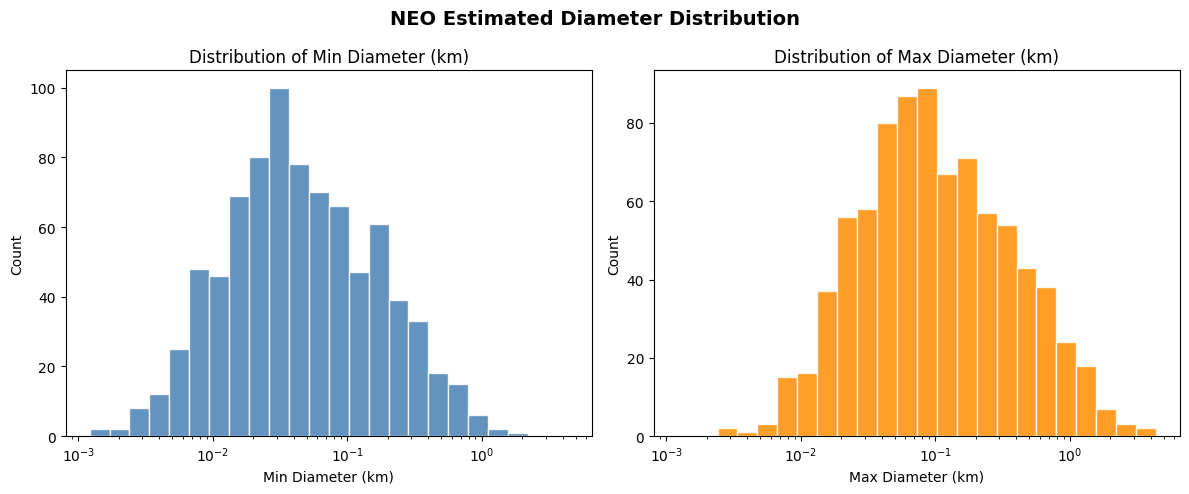

In [11]:
bins = np.logspace(
    np.log10(asteroids_df["estimated_diameter_min_km"].min()),
    np.log10(asteroids_df["estimated_diameter_max_km"].max()),
    25,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label, color in zip(
    axes,
    ["estimated_diameter_min_km", "estimated_diameter_max_km"],
    ["Min Diameter (km)", "Max Diameter (km)"],
    ["steelblue", "darkorange"],
):
    ax.hist(asteroids_df[col], bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.set_xscale("log")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {label}")

fig.suptitle("NEO Estimated Diameter Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Summary

Both histograms use a **logarithmic x-axis** to accommodate the wide spread of the diameter distribution — on a linear scale, the tail driven by a few large asteroids would compress the bulk of the data into an unreadable cluster near zero.

With 828 asteroids, the distribution takes on a roughly **log-normal shape** — approximately bell-shaped on the log scale, peaking in the 0.03–0.1 km range. The right tail extends to ~1.96 km (min) and ~4.39 km (max), driven by a small number of notably large objects including 1943 Anteros at the top of the ranking. The min and max diameter plots share the same overall shape, as expected — max is a scaled-up version of min based on NASA's size estimation model.

### 4.2.3 Identify Largest Objects

In [12]:
top20 = (
    asteroids_df[["asteroid_id", "name", "estimated_diameter_min_km", "estimated_diameter_max_km"]]
    .sort_values("estimated_diameter_max_km", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20.index += 1
top20.index.name = "rank"

display(top20)

,asteroid_id,name,estimated_diameter_min_km,estimated_diameter_max_km
rank,,,,
1,2001943,1943 Anteros (1973 EC),1.961349,4.385711
2,2248590,248590 (2006 CS),1.481000,3.311616
3,2418265,418265 (2008 EA32),1.338305,2.992540
4,2318411,318411 (2005 AH14),1.001279,2.238927
5,2017182,17182 (1999 VU),0.996678,2.228640
6,2374038,374038 (2004 HW),0.987541,2.208208
7,2500080,500080 (2011 WV134),0.969516,2.167904
8,2054071,54071 (2000 GQ146),0.872077,1.950024
9,2088710,88710 (2001 SL9),0.799015,1.786652


### 4.2.4 Interpret Findings

**Skewness**

The diameter distribution is right-skewed. The mean (~0.104 km min / ~0.233 km max) is more than 2× the median (~0.040 km min / ~0.090 km max), signaling that a small number of large asteroids pull the average upward. On a log scale (4.2.2), the distribution appears roughly log-normal — most objects cluster in a well-defined central range, with a long right tail.

**Rarity of Large Objects**

Large NEOs are uncommon in this dataset. Q3 sits at 0.253 km (max diameter), yet the largest object — 1943 Anteros — reaches ~4.39 km, roughly 17× above the third quartile. The top 20 list (4.2.3) shows that all 20 largest asteroids exceed 1 km in maximum estimated diameter, representing less than 2.5% of the 828-asteroid dataset. This is consistent with the known real-world pattern: small asteroids vastly outnumber large ones.

**Implications**

- **Hazard assessment:** Larger asteroids carry significantly higher impact energy. Although rare, km-scale NEOs making close approaches warrant close monitoring regardless of their statistical infrequency.
- **Statistical analysis:** The mean is not representative of a typical asteroid in this dataset; the median is a more appropriate central measure given the skew.
- **Modeling:** Any size-dependent analysis (e.g., correlating diameter with miss distance or velocity) should account for this skew, either through log-transformation or by treating the largest objects as a distinct subgroup.

## Velocity Analysis

### 4.3.1 Relative Velocity Distribution

In [13]:
velocity_stats = (
    close_approaches_df["relative_velocity_kps"]
    .agg(["mean", "median", "var"])
    .rename({"var": "variance"})
    .to_frame("relative_velocity_kps")
)

display(velocity_stats)

,relative_velocity_kps
mean,13.781163
median,13.105665
variance,50.531731


#### Summary

| Statistic | relative_velocity_kps |
|---|---|
| mean | 13.781163 |
| median | 13.105665 |
| variance | 50.531731 |

The mean (~13.8 km/s) sits slightly above the median (~13.1 km/s), indicating a mild right skew — a small number of faster-moving approaches pull the average up. The standard deviation (~7.1 km/s, √50.5) is substantial relative to the mean, reflecting genuine spread in approach velocities across the dataset rather than a tightly clustered population.

### 4.3.2 Visualize Velocity Distribution

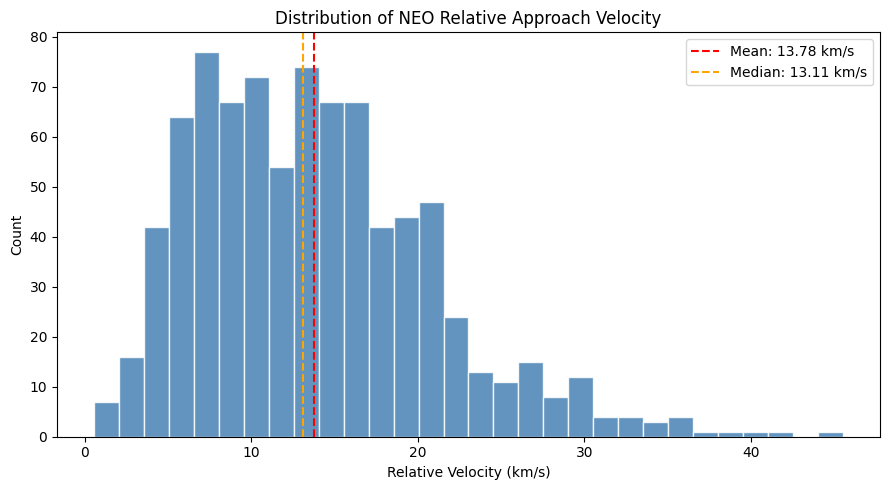

In [14]:
mean_vel = close_approaches_df["relative_velocity_kps"].mean()
median_vel = close_approaches_df["relative_velocity_kps"].median()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    close_approaches_df["relative_velocity_kps"],
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.axvline(mean_vel, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_vel:.2f} km/s")
ax.axvline(median_vel, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_vel:.2f} km/s")

ax.set_xlabel("Relative Velocity (km/s)")
ax.set_ylabel("Count")
ax.set_title("Distribution of NEO Relative Approach Velocity")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

The histogram confirms the mild right skew noted in 4.3.1. The bulk of close approaches fall between **5–20 km/s**, with the distribution peaking around 7–8 km/s before tapering into a right tail that extends to ~45 km/s. The mean (13.78 km/s, red) and median (13.11 km/s, orange) are close together and both sit near the center of the main cluster — the small gap between them reflects the modest pull of the faster-moving tail. A secondary cluster is visible around 18–22 km/s, suggesting a subset of approaches with distinctly higher velocities. No approaches were found at near-zero velocity, consistent with the impossible-values check in 4.1.4.

### 4.3.3 Identify Fastest Recorded Approaches

In [15]:
top20_velocity = (
    close_approaches_df
    .merge(asteroids_df[["asteroid_id", "name"]], on="asteroid_id", how="left")
    [["name", "asteroid_id", "close_approach_date", "relative_velocity_kps", "miss_distance_km"]]
    .sort_values("relative_velocity_kps", ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top20_velocity.index += 1
top20_velocity.index.name = "rank"

display(top20_velocity)

,name,asteroid_id,close_approach_date,relative_velocity_kps,miss_distance_km
rank,,,,,
1,(2013 LC7),3639550,2026-05-31,45.517616,6.704966e+07
2,(2008 JN),3409988,2026-04-24,41.977651,6.508094e+07
3,(2015 TD323),3731242,2026-04-26,40.420044,6.358159e+07
4,(2018 CW13),3799637,2026-02-09,39.067110,6.770498e+07
5,276033 (2002 AJ129),2276033,2026-02-09,37.703531,1.396260e+07
6,679657 (2020 BE15),2679657,2026-02-10,35.922253,2.218187e+07
7,(2020 BE15),3989350,2026-02-10,35.922250,2.218185e+07
8,(2011 UD256),3584579,2026-05-22,35.606616,6.209497e+07
9,(2002 UQ12),3141525,2026-06-12,35.316678,7.010881e+07


#### Analysis

The top 20 fastest approaches all occurred in **2026**, consistent with the current database date range. Velocities range from ~30.7 to 45.5 km/s — roughly 2–3× the dataset mean of 13.78 km/s — confirming these represent the far right tail of the distribution seen in 4.3.2.

The fastest recorded approach is **(2013 LC7)** at **45.52 km/s** on 2026-05-31. Despite its high speed, its miss distance (~6.7×10⁷ km) is large. In fact, all 20 entries have miss distances in the tens of millions of km, indicating that high velocity alone does not correlate with proximity in this dataset.

Two pairs of near-duplicate entries are visible:
- **Ranks 6 & 7** — `679657 (2020 BE15)` and `(2020 BE15)` share the same date (2026-02-10) and virtually identical velocity and miss distance, suggesting the same physical object recorded under two different asteroid IDs.
- **Ranks 18 & 19** — `(2018 LC3)` and `620103 (2018 LC3)` show the same pattern on 2026-01-01.

These pairs may reflect catalog alias entries in the NASA NeoWs API and are worth flagging for any deduplication logic in future pipeline work.

### 4.3.4 Interpret Velocity Findings

**Spread**

Relative approach velocities span a wide range across the dataset, with a standard deviation of ~7.1 km/s against a mean of ~13.8 km/s. This high coefficient of variation (~51%) reflects genuine diversity in the orbital geometries of tracked NEOs rather than measurement noise — different asteroids cross Earth's orbit at fundamentally different speeds depending on their eccentricity, inclination, and the geometry of the encounter. The interquartile range captures a moderately broad central population, while the histogram (4.3.2) shows a secondary cluster around 18–22 km/s, suggesting a distinct subset of faster-orbiting objects within the dataset.

**Extreme Values**

The fastest recorded approach — **(2013 LC7)** at **45.52 km/s** on 2026-05-31 — is more than 3× the dataset mean and represents the outermost point of the right tail. The top 20 fastest approaches (4.3.3) all exceed 30 km/s and all occurred in 2026, consistent with the current data range. Two pairs of near-duplicate entries were identified (2020 BE15, 2018 LC3), likely catalog aliases in the NASA NeoWs API, which artificially inflate the apparent count of extreme-velocity events.

**Possible Significance**

- **Hazard context:** Velocity is a key factor in impact energy (kinetic energy scales with v²), so the fastest-moving objects carry disproportionately higher potential impact energy even at smaller sizes. A 45 km/s approach delivers roughly 10× the kinetic energy of a 13 km/s approach for the same mass.
- **Miss distance independence:** High velocity does not predict a closer pass — the top 20 fastest approaches all had large miss distances (tens of millions of km). Hazard assessment requires evaluating velocity and miss distance together, not either alone.
- **Orbital interpretation:** Extreme velocities are consistent with high-inclination or high-eccentricity orbits. Cross-referencing with `orbital_parameters` (e.g., `inclination`, `eccentricity`) could confirm this in later analysis.

## Close Approach Analysis

### 4.4.1 Analyze Miss Distance Distribution

In [16]:
miss_distance_stats = (
    close_approaches_df["miss_distance_km"]
    .agg(["median", "min", "max"])
    .to_frame("miss_distance_km")
)

display(miss_distance_stats)

,miss_distance_km
median,3.606071e+07
min,2.605281e+05
max,7.477661e+07


#### Summary

| Statistic | miss_distance_km |
|---|---|
| min | 2.605281e+05 (~260,528 km) |
| median | 3.606071e+07 (~36.1 million km) |
| max | 7.477661e+07 (~74.8 million km) |

The most striking figure is the **minimum: ~260,528 km** — closer than the Moon (~384,400 km). This represents a genuinely close encounter by planetary standards. The median of ~36.1 million km indicates that most approaches pass at comfortable distances, while the max of ~74.8 million km sits near the outer edge of what NASA classifies as a close approach. The wide spread between min and max (~287× difference) suggests the distribution will be broad and likely right-skewed.

### 4.4.2 Visualize Miss Distance Distribution

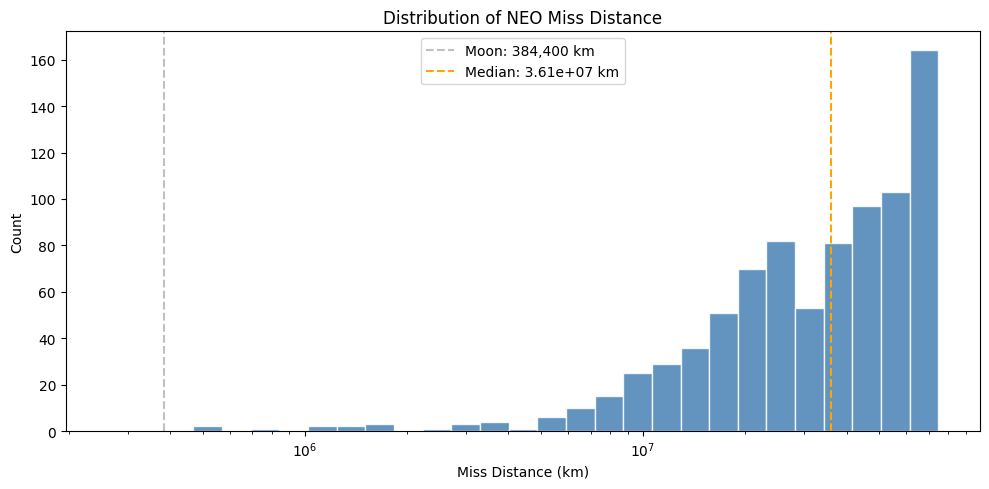

In [17]:
MOON_DISTANCE_KM = 384_400

bins = np.logspace(
    np.log10(close_approaches_df["miss_distance_km"].min()),
    np.log10(close_approaches_df["miss_distance_km"].max()),
    30,
)

median_dist = close_approaches_df["miss_distance_km"].median()

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    close_approaches_df["miss_distance_km"],
    bins=bins,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.axvline(MOON_DISTANCE_KM, color="silver", linestyle="--", linewidth=1.5, label=f"Moon: {MOON_DISTANCE_KM:,} km")
ax.axvline(median_dist, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_dist:.2e} km")

ax.set_xscale("log")
ax.set_xlabel("Miss Distance (km)")
ax.set_ylabel("Count")
ax.set_title("Distribution of NEO Miss Distance")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

The log-scale histogram reveals a distribution that rises steadily toward larger distances — the opposite shape from diameter and velocity. The vast majority of approaches in this dataset occur at distances of **10 million km or more**, with counts increasing as distance increases toward the dataset maximum of ~74.8 million km.

The Moon reference line (gray, ~384,400 km) sits at the far left edge of the chart, with only a handful of approaches falling within lunar distance — visually confirming that sub-lunar encounters are rare but present. The median (~3.61×10⁷ km, orange) falls roughly in the middle of the log range but to the left of where most approaches cluster, reflecting the rightward lean of the distribution.

This pattern is consistent with how NASA's NeoWs API captures close approaches: the pool of possible encounters grows with distance (more orbital paths intersect at larger radii), so larger miss distances are naturally more common within the tracking window.

### 4.4.3 Identify Closest Approaches

In [18]:
merge_cols = ["asteroid_id", "name", "estimated_diameter_max_km", "is_potentially_hazardous"]
select_cols = [
    "name", "asteroid_id", "close_approach_date", "miss_distance_km",
    "relative_velocity_kps", "estimated_diameter_max_km", "is_potentially_hazardous",
]

top20_closest = (
    close_approaches_df
    .merge(asteroids_df[merge_cols], on="asteroid_id", how="left")
    [select_cols]
    .sort_values("miss_distance_km", ascending=True)
    .head(20)
    .reset_index(drop=True)
)
top20_closest.index += 1
top20_closest.index.name = "rank"

display(top20_closest)

,name,asteroid_id,close_approach_date,miss_distance_km,relative_velocity_kps,estimated_diameter_max_km,is_potentially_hazardous
rank,,,,,,,
1,(2013 GM3),3634154,2026-04-14,2.605281e+05,7.409508,0.032662,False
2,(2026 EK1),54606183,2026-03-08,5.621758e+05,10.676622,0.031020,False
3,(2015 EX),3713008,2026-03-08,5.623196e+05,10.679081,0.037328,False
4,(2026 BV),54576849,2026-01-16,7.207621e+05,9.944471,0.014711,False
5,(2015 VO142),3735181,2026-03-17,1.034242e+06,3.092623,0.009864,False
6,(2026 FM),54606465,2026-03-16,1.138334e+06,4.698301,0.017189,False
7,(2011 FT9),3560131,2026-04-07,1.321186e+06,5.871518,0.034201,False
8,(2003 LN6),3156302,2026-06-18,1.417040e+06,3.920081,0.067927,False
9,(2024 CW2),54426230,2026-03-15,1.703647e+06,7.773114,0.080805,False


#### Analysis

The closest approach belongs to **(2013 GM3)** on 2026-04-14, passing at **~260,528 km** — well inside the Moon's average distance of ~384,400 km. Despite this remarkable proximity, the object is small (~33 meters max diameter) and not classified as potentially hazardous, so it poses minimal risk.

The most operationally significant entry is **rank 12: 152637 (1997 NC1)** — the only potentially hazardous asteroid (`is_potentially_hazardous = True`) in the top 20, with a maximum estimated diameter of **~1.59 km** and a miss distance of ~2.57 million km on 2026-06-27. It also appears in the top 20 largest objects list (4.2.3), making it the highest-concern approach in the dataset when size and hazard classification are considered together.

Two more alias pairs appear in this table:
- **Ranks 2 & 3** — `(2026 EK1)` and `(2015 EX)` share the same date (2026-03-08) with nearly identical miss distances and velocities.
- **Ranks 16 & 17** — `(2007 DB61)` and `887773 (2007 DB61)` are identical on 2026-02-21 — another catalog alias pair like those identified in 4.3.3.

All 20 approaches occur in 2026, and notably all closest encounters are relatively slow (mostly 3–11 km/s), well below the dataset mean of 13.8 km/s — consistent with the finding from 4.3.4 that proximity and velocity are independent.

### 4.4.4 Analyze Approach Frequency

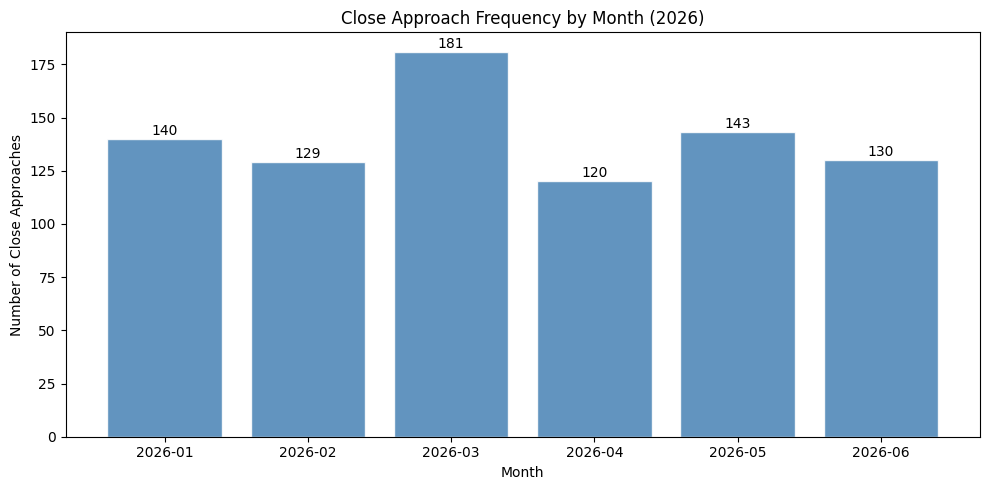

In [19]:
monthly_counts = (
    close_approaches_df["close_approach_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

counts = monthly_counts.to_numpy()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    monthly_counts.index.astype(str),
    counts,
    color="steelblue",
    edgecolor="white",
    alpha=0.85,
)

ax.set_xlabel("Month")
ax.set_ylabel("Number of Close Approaches")
ax.set_title("Close Approach Frequency by Month (2026)")

for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

#### Summary

| Month | Close Approaches |
|---|---|
| 2026-01 | 140 |
| 2026-02 | 129 |
| 2026-03 | 181 |
| 2026-04 | 120 |
| 2026-05 | 143 |
| 2026-06 | 130 |

**March 2026** is the busiest month with 181 approaches (~21% of the 843 total), while **April 2026** is the quietest at 120. The range across months is 61 approaches, suggesting moderate variation rather than a dramatic seasonal pattern — the monthly average is ~140.5 approaches.

One caveat: **June is incomplete** (data runs through June 24 only). Its 130 approaches across ~24 days would likely exceed most other months if extrapolated to a full 30 days (~162 projected), suggesting the dataset may have a natural cutoff effect on the final month rather than a genuine drop in activity.

### 4.4.5 Interpret Findings

**Clustering**

Miss distances are not uniformly spread — they cluster heavily at larger distances (10 million km and above), as shown by the rising histogram in 4.4.2. Very close approaches (sub-lunar or within a few million km) are rare outliers. In time, March 2026 shows the strongest clustering of encounters with 181 approaches in a single month. The closest-approach table (4.4.3) also reveals spatial clustering through catalog alias pairs: the same physical object appearing under two different IDs on the same date inflates apparent encounter counts at specific distances. Four such alias pairs were identified across 4.3.3 and 4.4.3 (2020 BE15, 2018 LC3, 2026 EK1 / 2015 EX, 2007 DB61).

**Trends**

Monthly approach frequency is relatively stable across the dataset, ranging from 120 (April) to 181 (March), with an average of ~140 per month. There is no strong directional trend within the 6-month window — counts rise in March, dip in April, recover in May, and taper in June. However, June is only partially captured (through June 24), so the apparent drop is likely a data truncation effect rather than a real decline. With only a single year of data, it is not possible to assess whether the March peak reflects a recurring seasonal pattern or is specific to 2026.

**Limitations**

- **Date range:** The dataset covers January–June 2026 only. Multi-year trends, seasonal patterns, and long-term changes in approach frequency cannot be assessed.
- **Incomplete final month:** June 2026 has only 24 days of data, understating its true approach count relative to other months.
- **Catalog aliases:** Multiple asteroid IDs mapping to the same physical object create near-duplicate rows in `close_approaches`, slightly inflating total counts and skewing ranked tables. This is an upstream data quality issue from the NASA NeoWs API.
- **Missing orbital data:** 4 records in `orbital_parameters.data_arc_in_days` are null (introduced with the database update), which may affect any future analysis that relies on observational arc length.
- **Single orbiting body:** All approaches in the dataset are relative to Earth — no multi-body comparison is possible with the current schema.

## Hazardous Object Population Study

### 4.5.1 Segment Hazardous vs Non-Hazardous Objects

In [20]:
hazardous_df = asteroids_df[asteroids_df["is_potentially_hazardous"]].copy()
non_hazardous_df = asteroids_df[~asteroids_df["is_potentially_hazardous"]].copy()

total = len(asteroids_df)
summary = pd.DataFrame({
    "count": [len(hazardous_df), len(non_hazardous_df), total],
    "percentage": [
        len(hazardous_df) / total * 100,
        len(non_hazardous_df) / total * 100,
        100.0,
    ],
}, index=["Potentially Hazardous", "Non-Hazardous", "Total"])
summary["percentage"] = summary["percentage"].map("{:.2f}%".format)

display(summary)

,count,percentage
Potentially Hazardous,90,10.87%
Non-Hazardous,738,89.13%
Total,828,100.00%


### 4.5.2 Compare Diameter Characteristics

,Hazardous (n=90),Non-Hazardous (n=738)
mean,0.588092,0.189285
median,0.428593,0.077990
std,0.404883,0.358313
min,0.245493,0.002717
max,2.208208,4.385711


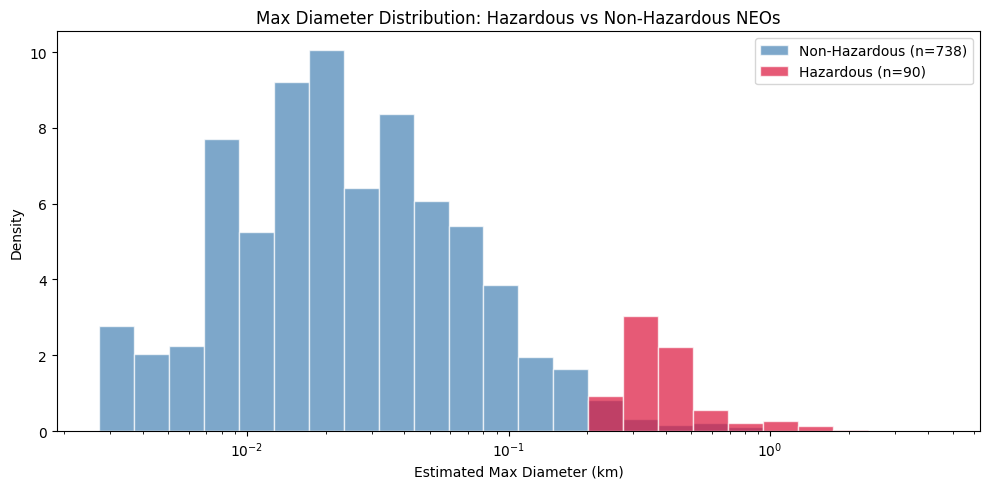

In [21]:
diameter_col = "estimated_diameter_max_km"

diameter_comparison = pd.DataFrame({
    "Hazardous (n=90)": hazardous_df[diameter_col].agg(["mean", "median", "std", "min", "max"]),
    "Non-Hazardous (n=738)": non_hazardous_df[diameter_col].agg(["mean", "median", "std", "min", "max"]),
}).round(6)

display(diameter_comparison)

bins = np.logspace(
    np.log10(asteroids_df[diameter_col].min()),
    np.log10(asteroids_df[diameter_col].max()),
    25,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(non_hazardous_df[diameter_col], bins=bins, density=True,
        color="steelblue", edgecolor="white", alpha=0.7, label="Non-Hazardous (n=738)")
ax.hist(hazardous_df[diameter_col], bins=bins, density=True,
        color="crimson", edgecolor="white", alpha=0.7, label="Hazardous (n=90)")

ax.set_xscale("log")
ax.set_xlabel("Estimated Max Diameter (km)")
ax.set_ylabel("Density")
ax.set_title("Max Diameter Distribution: Hazardous vs Non-Hazardous NEOs")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

| Statistic | Hazardous (n=90) | Non-Hazardous (n=738) |
|---|---|---|
| mean | 0.588092 km | 0.189285 km |
| median | 0.428593 km | 0.077990 km |
| std | 0.404883 km | 0.358313 km |
| min | 0.245493 km | 0.002717 km |
| max | 2.208208 km | 4.385711 km |

Hazardous asteroids are **substantially larger** on every central measure. The median PHO (~429 m) is roughly **5.5× larger** than the median non-hazardous asteroid (~78 m). The mean gap is even wider (~3.1×). This is expected: NASA's PHO definition requires an absolute magnitude H ≤ 22, which corresponds to a minimum diameter of roughly 140 m — so small objects cannot be classified as hazardous regardless of their orbit.

The non-hazardous group has a higher maximum (4.39 km vs 2.21 km) because large asteroids with favorable orbits can exceed the hazard size threshold yet never come close enough to Earth to qualify as PHOs. The density-normalized histogram makes the size separation visually clear: the hazardous distribution (crimson) is shifted distinctly to the right of the non-hazardous distribution (blue).

### 4.5.3 Compare Velocity Characteristics

,Hazardous (n=90),Non-Hazardous (n=753)
mean,16.645029,13.438868
median,16.525060,12.715209
std,7.368236,7.003936
min,4.455313,0.562827
max,40.420044,45.517616


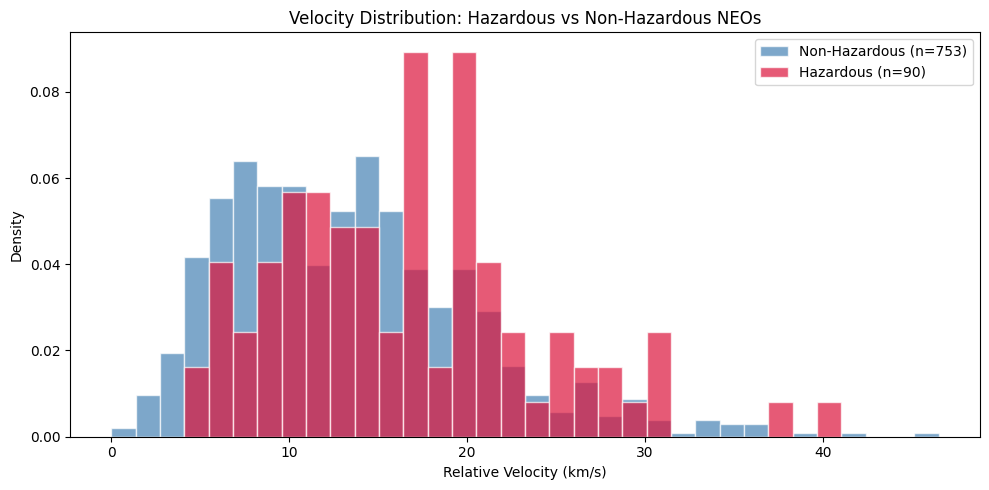

In [22]:
hazardous_ca = close_approaches_df[close_approaches_df["asteroid_id"].isin(hazardous_df["asteroid_id"])]
non_hazardous_ca = close_approaches_df[close_approaches_df["asteroid_id"].isin(non_hazardous_df["asteroid_id"])]

agg_stats = ["mean", "median", "std", "min", "max"]
velocity_comparison = pd.DataFrame({
    f"Hazardous (n={len(hazardous_ca)})": hazardous_ca["relative_velocity_kps"].agg(agg_stats),
    f"Non-Hazardous (n={len(non_hazardous_ca)})": non_hazardous_ca["relative_velocity_kps"].agg(agg_stats),
}).round(6)

display(velocity_comparison)

bins = np.linspace(0, close_approaches_df["relative_velocity_kps"].max() + 1, 35)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(non_hazardous_ca["relative_velocity_kps"], bins=bins, density=True,
        color="steelblue", edgecolor="white", alpha=0.7, label=f"Non-Hazardous (n={len(non_hazardous_ca)})")
ax.hist(hazardous_ca["relative_velocity_kps"], bins=bins, density=True,
        color="crimson", edgecolor="white", alpha=0.7, label=f"Hazardous (n={len(hazardous_ca)})")

ax.set_xlabel("Relative Velocity (km/s)")
ax.set_ylabel("Density")
ax.set_title("Velocity Distribution: Hazardous vs Non-Hazardous NEOs")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

| Statistic | Hazardous (n=90) | Non-Hazardous (n=753) |
|---|---|---|
| mean | 16.645029 km/s | 13.438868 km/s |
| median | 16.525060 km/s | 12.715209 km/s |
| std | 7.368236 km/s | 7.003936 km/s |
| min | 4.455313 km/s | 0.562827 km/s |
| max | 40.420044 km/s | 45.517616 km/s |

Hazardous asteroids approach at **higher velocities on average** — a median of ~16.5 km/s vs ~12.7 km/s for non-hazardous objects (~30% faster). This is consistent with the orbital dynamics underlying PHO classification: hazardous asteroids tend to have higher eccentricities and inclinations, which produce more energetic Earth-crossing geometries.

Unlike the diameter comparison, the velocity distributions **do overlap substantially** — both groups span a similar range and have comparable standard deviations (~7 km/s). Velocity alone is therefore a weak discriminator between the two groups; the offset in the mean is real but the spread is large. The fastest approach in the dataset (45.52 km/s) belongs to a non-hazardous asteroid, confirming that extreme velocities are not exclusive to PHOs.

### 4.5.4 Compare Miss Distance Characteristics

,Hazardous (n=90),Non-Hazardous (n=753)
mean,28466396.28,39229818.75
median,21046232.88,37884072.69
std,20449306.30,20839267.15
min,2565841.00,260528.06
max,73421658.35,74776614.53


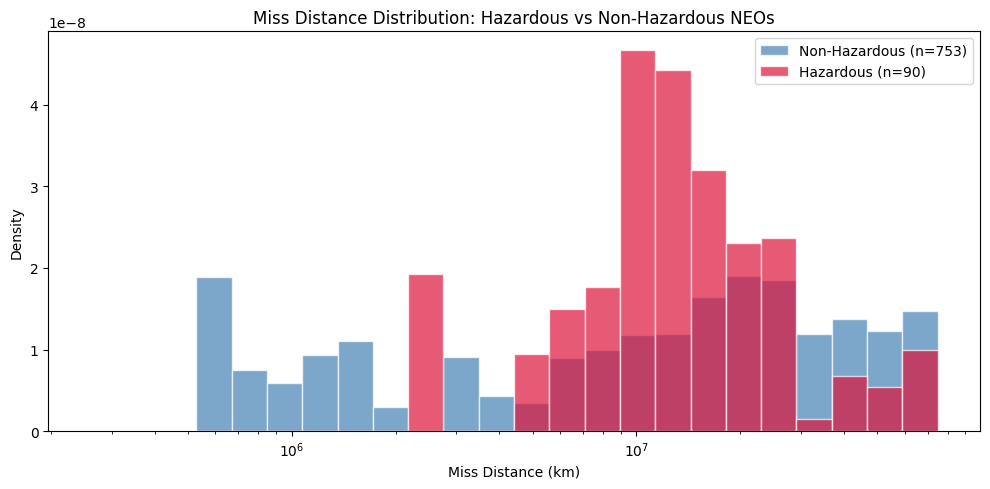

In [23]:
miss_col = "miss_distance_km"

miss_comparison = pd.DataFrame({
    f"Hazardous (n={len(hazardous_ca)})": hazardous_ca[miss_col].agg(agg_stats),
    f"Non-Hazardous (n={len(non_hazardous_ca)})": non_hazardous_ca[miss_col].agg(agg_stats),
}).round(2)

display(miss_comparison)

bins = np.logspace(
    np.log10(close_approaches_df[miss_col].min()),
    np.log10(close_approaches_df[miss_col].max()),
    25,
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(non_hazardous_ca[miss_col], bins=bins, density=True,
        color="steelblue", edgecolor="white", alpha=0.7, label=f"Non-Hazardous (n={len(non_hazardous_ca)})")
ax.hist(hazardous_ca[miss_col], bins=bins, density=True,
        color="crimson", edgecolor="white", alpha=0.7, label=f"Hazardous (n={len(hazardous_ca)})")

ax.set_xscale("log")
ax.set_xlabel("Miss Distance (km)")
ax.set_ylabel("Density")
ax.set_title("Miss Distance Distribution: Hazardous vs Non-Hazardous NEOs")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

| Statistic | Hazardous (n=90) | Non-Hazardous (n=753) |
|---|---|---|
| mean | 28,466,396 km | 39,229,819 km |
| median | 21,046,233 km | 37,884,073 km |
| std | 20,449,306 km | 20,839,267 km |
| min | 2,565,841 km | 260,528 km |
| max | 73,421,658 km | 74,776,615 km |

Hazardous asteroids pass closer to Earth on average — median ~21.0M km vs ~37.9M km for non-hazardous, roughly **1.8× closer**. This follows directly from the PHO classification criteria: NASA's definition requires a Minimum Orbit Intersection Distance (MOID) ≤ 0.05 AU (~7.48M km), meaning PHOs are specifically the asteroids whose orbital paths come within that threshold of Earth's orbit. The classification selects for proximity by design, so smaller miss distances in this group are expected.

The histogram reflects this clearly — hazardous approaches (crimson) are concentrated in the 10–50M km band, while non-hazardous approaches (blue) spread more flatly across the full range, with a higher density at large distances.

Notably, the closest absolute approach in the dataset (~261K km, sub-lunar) belongs to a **non-hazardous** asteroid, (2013 GM3). The closest hazardous approach is ~2.57M km (152637 (1997 NC1) on 2026-06-27), consistent with rank 12 in the closest-approaches table (4.4.3). Both groups share a similar upper bound (~73–75M km), reflecting the outer edge of NASA's close-approach tracking window rather than a physical difference. The standard deviations (~20M km each) confirm the spread is comparable between groups — the separation is in the center, not the tails.

### 4.5.5 Identify Potential Predictive Features

,feature,correlation
rank,,
1,absolute_magnitude_h,-0.4311
2,estimated_diameter_max_km,0.3234
3,eccentricity,0.2335
4,min_miss_distance_km,-0.1588
5,aphelion_distance,0.1535
6,perihelion_distance,-0.1452
7,inclination,0.1420
8,minimum_orbit_intersection,-0.1382
9,max_relative_velocity_kps,0.1340


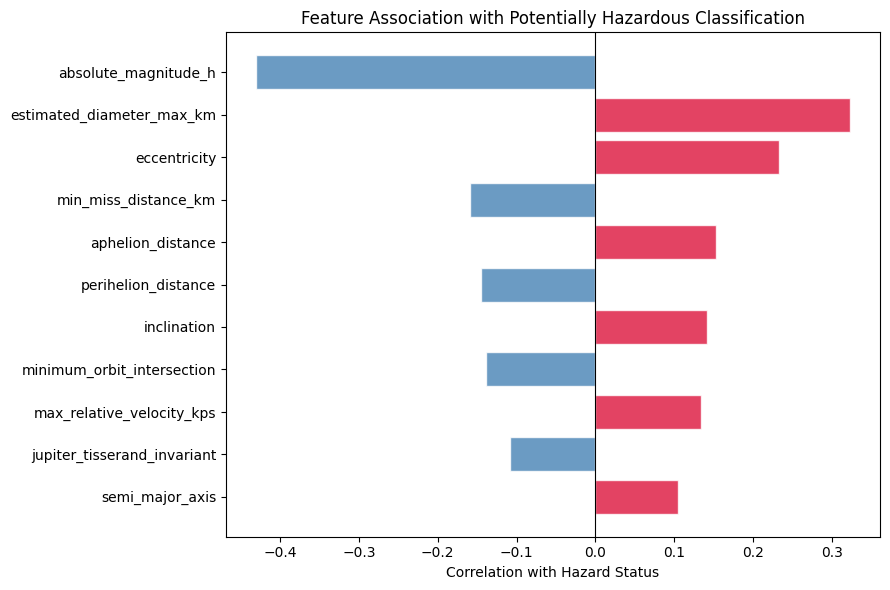

In [24]:

# Per-asteroid close approach aggregates
ca_agg = (
    close_approaches_df
    .groupby("asteroid_id")
    .agg(
        min_miss_distance_km=("miss_distance_km", "min"),
        max_relative_velocity_kps=("relative_velocity_kps", "max"),
    )
    .reset_index()
)

# Build asteroid-level feature matrix
orbital_cols = [
    "asteroid_id", "minimum_orbit_intersection", "eccentricity",
    "inclination", "semi_major_axis", "perihelion_distance",
    "aphelion_distance", "jupiter_tisserand_invariant",
]

features_df = (
    asteroids_df[["asteroid_id", "absolute_magnitude_h",
                  "estimated_diameter_max_km", "is_potentially_hazardous"]]
    .merge(orbital_parameters_df[orbital_cols], on="asteroid_id", how="left")
    .merge(ca_agg, on="asteroid_id", how="left")
)

# Point-biserial correlation (equivalent to Pearson for binary target)
feature_cols = [
    c for c in features_df.columns
    if c not in ("asteroid_id", "is_potentially_hazardous")
]
target = features_df["is_potentially_hazardous"].astype(int)

corr_df = (
    features_df[feature_cols]
    .corrwith(target)
    .rename("correlation")
    .to_frame()
    .assign(abs_corr=lambda df: df["correlation"].abs())
    .sort_values("abs_corr", ascending=False)
    .drop(columns="abs_corr")
    .round(4)
)
corr_df.index.name = "feature"
corr_df = corr_df.reset_index()
corr_df.index += 1
corr_df.index.name = "rank"

display(corr_df)

# Horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 6))

features_rev = corr_df["feature"][::-1].tolist()
corrs_rev = corr_df["correlation"][::-1].tolist()
bar_colors = ["crimson" if r >= 0 else "steelblue" for r in corrs_rev]

ax.barh(features_rev, corrs_rev, color=bar_colors, edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Correlation with Hazard Status")
ax.set_title("Feature Association with Potentially Hazardous Classification")

plt.tight_layout()
plt.show()


#### Summary

Correlations are computed as point-biserial (equivalent to Pearson for a binary target), ranked by absolute value across 11 candidate features.

| Rank | Feature | Correlation | Interpretation |
|---|---|---|---|
| 1 | `absolute_magnitude_h` | −0.4311 | Smaller H (brighter/larger) → more likely hazardous |
| 2 | `estimated_diameter_max_km` | +0.3234 | Larger diameter → more likely hazardous |
| 3 | `eccentricity` | +0.2335 | More elongated orbit → more likely hazardous |
| 4 | `min_miss_distance_km` | −0.1588 | Closer minimum pass → more likely hazardous |
| 5 | `aphelion_distance` | +0.1535 | Orbit extends further out → more likely hazardous |
| 6 | `perihelion_distance` | −0.1452 | Orbit dips closer to the Sun → more likely hazardous |
| 7 | `inclination` | +0.1420 | Higher orbital tilt → more likely hazardous |
| 8 | `minimum_orbit_intersection` | −0.1382 | Smaller MOID → more likely hazardous |
| 9 | `max_relative_velocity_kps` | +0.1340 | Faster approach speed → more likely hazardous |
| 10 | `jupiter_tisserand_invariant` | −0.1086 | Lower TJ → more likely hazardous |
| 11 | `semi_major_axis` | +0.1050 | Weakest individual signal |

**Size features dominate.** `absolute_magnitude_h` and `estimated_diameter_max_km` are the two strongest predictors, both reflecting NASA's H ≤ 22 size requirement built into the PHO definition. Because small asteroids (H > 22) vastly outnumber large ones in this dataset, the size criterion alone cleaves the hazardous from non-hazardous population more than any orbital feature.

**Eccentricity is the most informative orbital feature.** At |r| = 0.23, it is the only strong predictor that is independent of the PHO classification criteria themselves. Higher-eccentricity orbits are more likely to cross Earth's path at Earth-like distances, producing the physical association with hazard status that eccentricity captures.

**MOID ranks lower than expected.** `minimum_orbit_intersection` (rank 8, |r| = 0.14) is literally one of the two defining criteria for PHO classification (MOID ≤ 0.05 AU), yet it is weaker than the size features here. This is because the H ≤ 22 size requirement eliminates far more asteroids from PHO eligibility than the MOID threshold does in this sample — many non-hazardous asteroids have low MOIDs but are too small to qualify. The size signal therefore captures more variance across the full 828-asteroid dataset.

**No single feature is sufficient.** All correlations are below |r| = 0.5, meaning none of the individual features cleanly separates the two groups on its own. The findings from 4.5.2–4.5.4 are consistent with this: diameter shows near-complete separation, velocity shows heavy overlap, and miss distance falls in between. A reliable hazard classifier would need to combine multiple features — particularly size, eccentricity, and MOID — rather than rely on any one signal alone.

## Correlation & Relationship Analysis

### 4.6.1 Create Correlation Matrix

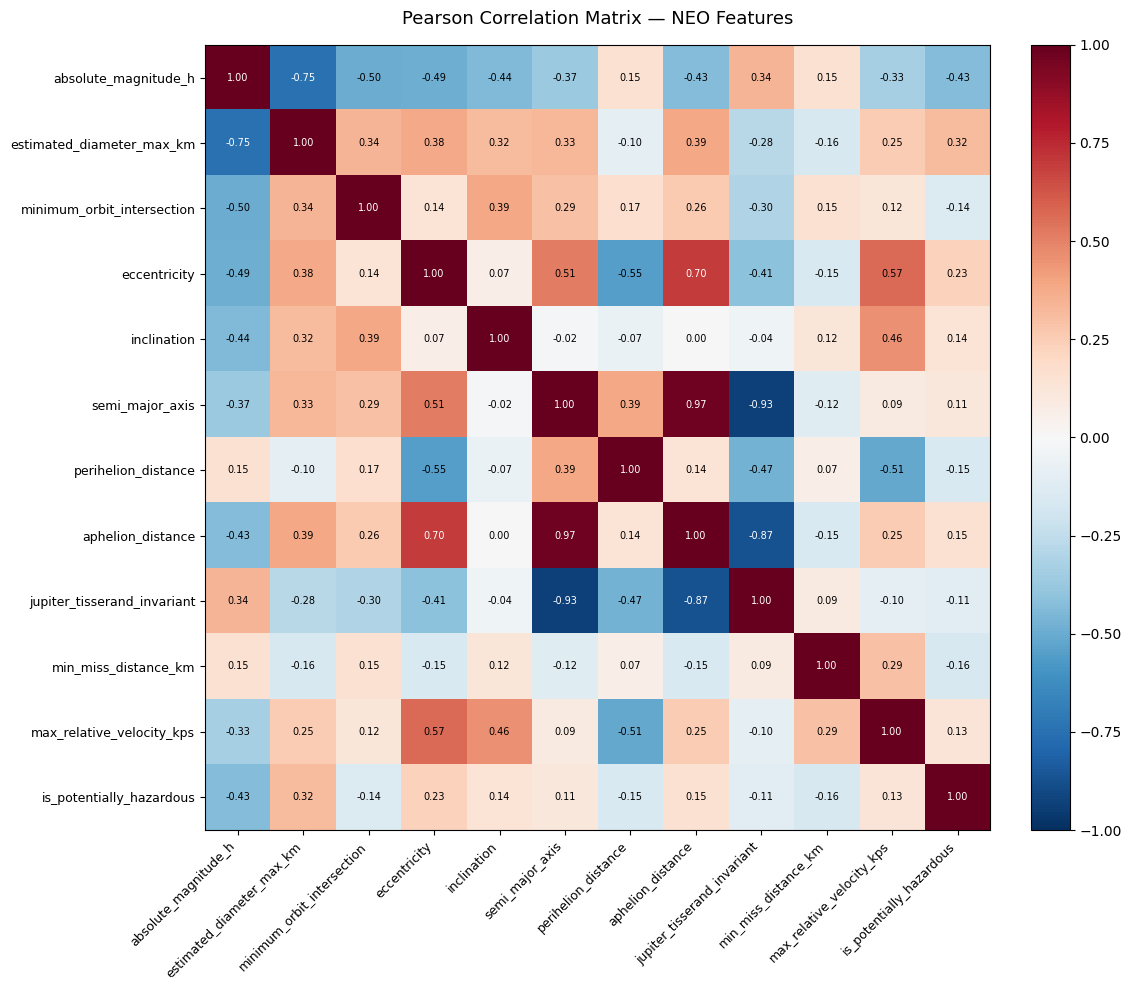

In [25]:
corr_matrix = (
    features_df[feature_cols]
    .assign(is_potentially_hazardous=features_df["is_potentially_hazardous"].astype(int))
    .corr()
    .round(2)
)

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(labels, fontsize=9)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        text_color = "white" if abs(val) > 0.6 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=7, color=text_color)

ax.set_title("Pearson Correlation Matrix — NEO Features", fontsize=13, pad=15)
plt.tight_layout()
plt.show()


### 4.6.2 Analyze Size vs Velocity

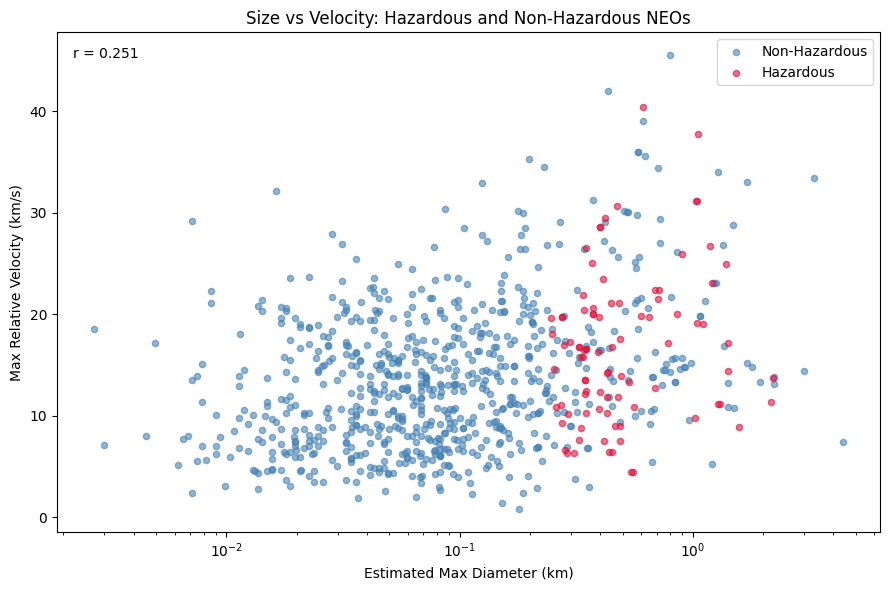

In [26]:
scatter_df = features_df[
    ["estimated_diameter_max_km", "max_relative_velocity_kps", "is_potentially_hazardous"]
].dropna()

r = scatter_df["estimated_diameter_max_km"].corr(scatter_df["max_relative_velocity_kps"])

fig, ax = plt.subplots(figsize=(9, 6))

for label, group_bool, color in [
    ("Non-Hazardous", False, "steelblue"),
    ("Hazardous", True, "crimson"),
]:
    mask = scatter_df["is_potentially_hazardous"] == group_bool
    ax.scatter(
        scatter_df.loc[mask, "estimated_diameter_max_km"],
        scatter_df.loc[mask, "max_relative_velocity_kps"],
        c=color, alpha=0.6, s=20, label=label,
    )

ax.set_xscale("log")
ax.set_xlabel("Estimated Max Diameter (km)")
ax.set_ylabel("Max Relative Velocity (km/s)")
ax.set_title("Size vs Velocity: Hazardous and Non-Hazardous NEOs")
ax.legend()
ax.text(0.02, 0.97, f"r = {r:.3f}", transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


### 4.6.3 Analyze Size vs Miss Distance

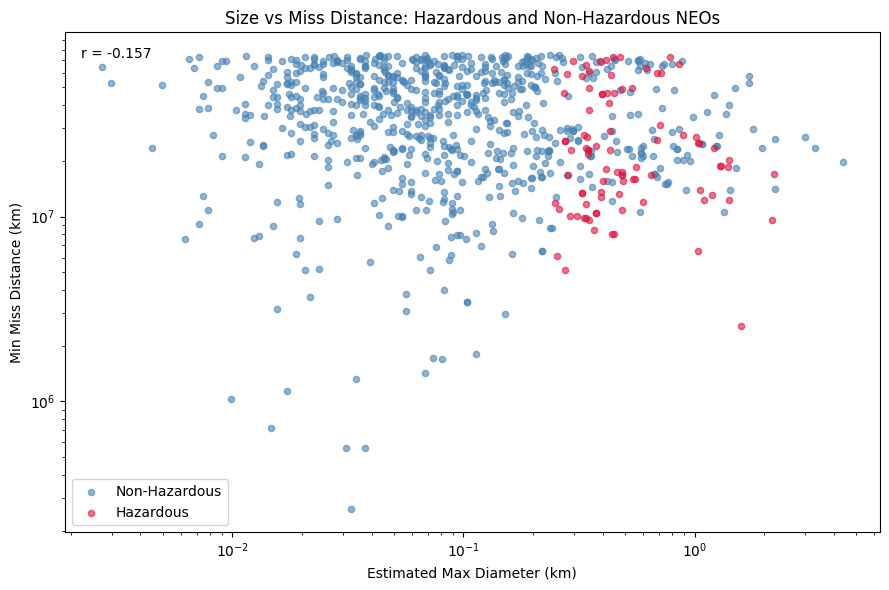

In [27]:
scatter_df2 = features_df[
    ["estimated_diameter_max_km", "min_miss_distance_km", "is_potentially_hazardous"]
].dropna()

r2 = scatter_df2["estimated_diameter_max_km"].corr(scatter_df2["min_miss_distance_km"])

fig, ax = plt.subplots(figsize=(9, 6))

for label, group_bool, color in [
    ("Non-Hazardous", False, "steelblue"),
    ("Hazardous", True, "crimson"),
]:
    mask = scatter_df2["is_potentially_hazardous"] == group_bool
    ax.scatter(
        scatter_df2.loc[mask, "estimated_diameter_max_km"],
        scatter_df2.loc[mask, "min_miss_distance_km"],
        c=color, alpha=0.6, s=20, label=label,
    )

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Estimated Max Diameter (km)")
ax.set_ylabel("Min Miss Distance (km)")
ax.set_title("Size vs Miss Distance: Hazardous and Non-Hazardous NEOs")
ax.legend()
ax.text(0.02, 0.97, f"r = {r2:.3f}", transform=ax.transAxes, va="top", fontsize=10)

plt.tight_layout()
plt.show()


### 4.6.4 Interpret Correlation Findings

#### Meaningful Relationships

**Orbital geometry clusters (r ≥ 0.87)**

The three strongest correlations in the matrix are between orbital parameters that are mathematically linked by Keplerian mechanics:

- `semi_major_axis` ↔ `aphelion_distance`: r = **0.97** — aphelion = a(1 + e), so for similar eccentricities, aphelion scales almost perfectly with semi-major axis. The near-perfect r reflects that variation in semi-major axis dominates over variation in eccentricity across this dataset.
- `semi_major_axis` ↔ `jupiter_tisserand_invariant`: r = **−0.93** — the Tisserand parameter TJ increases as an asteroid's orbit shrinks (smaller semi-major axis → higher TJ), producing the strong negative trend.
- `aphelion_distance` ↔ `jupiter_tisserand_invariant`: r = **−0.87** — a downstream consequence of the two above.

These three values are structural: they reflect the mathematics of orbital mechanics rather than independent physical properties. They are not useful as independent inputs to a risk model since they encode the same underlying orbital shape.

**Eccentricity as a velocity driver (r = 0.57)**

`eccentricity` ↔ `max_relative_velocity_kps`: r = **0.57** — more elongated orbits cross Earth's path at higher relative speeds. This is the strongest physically meaningful relationship between an orbital property and an observable approach characteristic. It is reinforced by `perihelion_distance` ↔ `max_relative_velocity_kps` (r = −0.51): orbits that dip closer to the Sun at perihelion produce faster encounters at Earth distance.

**Size ↔ magnitude (r = −0.75)**

`absolute_magnitude_h` ↔ `estimated_diameter_max_km`: r = **−0.75** — the expected inverse: smaller H means a brighter, larger object. These two columns measure the same physical property through different proxies (photometric vs. modeled diameter) and should not both be fed into a model as independent features.

---

#### Weak Relationships

**Size vs velocity (r = 0.251)**

The scatter plot (4.6.2) shows substantial spread with no clear trend — the r = 0.251 is statistically present but practically weak. Larger asteroids are marginally faster on average, but the velocity range is nearly identical for hazardous (crimson) and non-hazardous (blue) objects at any given size. Size and velocity are effectively independent properties of an asteroid; the slight positive correlation is an indirect effect of larger asteroids being more likely to be hazardous, and hazardous asteroids tending toward higher eccentricity.

**Size vs miss distance (r = −0.157)**

The log-log scatter (4.6.3) shows very weak negative correlation. Miss distance and diameter are largely independent — the modest trend reflects the MOID criterion pulling hazardous (larger) asteroids toward lower miss distances rather than any physical causal link between size and proximity.

**MOID as a predictor (r = −0.14 with hazard status)**

`minimum_orbit_intersection` correlates more strongly with `absolute_magnitude_h` (r = −0.50) than with `is_potentially_hazardous` (r = −0.14), despite MOID being one of the two defining PHO criteria. The reason: many non-hazardous asteroids have low MOIDs but are too small (H > 22) to qualify as PHOs. In this sample the size criterion eliminates far more candidates than the MOID threshold, so the MOID signal is diluted.

---

#### Surprises

**The closest approaches belong to non-hazardous asteroids.**

In the size vs miss distance plot (4.6.3), the bottom of the chart — the very closest observed passes — is populated entirely by non-hazardous asteroids (blue). The closest hazardous approach in the dataset is ~2.57M km (152637 (1997 NC1), 2026-06-27), while a non-hazardous asteroid reached ~261K km (2013 GM3, 2026-04-14). This seems to contradict the PHO classification, but reflects the difference between an orbit's MOID (minimum possible approach distance, used to classify PHOs) and the closest actual approach that happened to fall within the 6-month data window. A PHO's MOID may be ≤ 0.05 AU, but its observed pass in this period need not be anywhere near that minimum.

**Velocity increases with inclination (r = 0.46).**

`inclination` ↔ `max_relative_velocity_kps`: r = **0.46** is a moderately strong relationship that does not stand out visually in the heatmap but is physically meaningful: high-inclination orbits cross Earth's orbital plane at a steeper angle, adding a vertical velocity component that raises the total relative speed at closest approach. This is independent of eccentricity and represents a separate velocity pathway worth considering in a risk model.

## Outlier Investigation

### 4.7.1 Identify Largest Outliers

3× IQR upper fence: 0.8873 km
Outliers identified: 44


,asteroid_id,name,estimated_diameter_max_km,absolute_magnitude_h,is_potentially_hazardous
rank,,,,,
1,2001943,1943 Anteros (1973 EC),4.385711,15.66,False
2,2248590,248590 (2006 CS),3.311616,16.27,False
3,2418265,418265 (2008 EA32),2.992540,16.49,False
4,2318411,318411 (2005 AH14),2.238927,17.12,False
5,2017182,17182 (1999 VU),2.228640,17.13,False
6,2374038,374038 (2004 HW),2.208208,17.15,True
7,2500080,500080 (2011 WV134),2.167904,17.19,True
8,2054071,54071 (2000 GQ146),1.950024,17.42,False
9,2088710,88710 (2001 SL9),1.786652,17.61,False


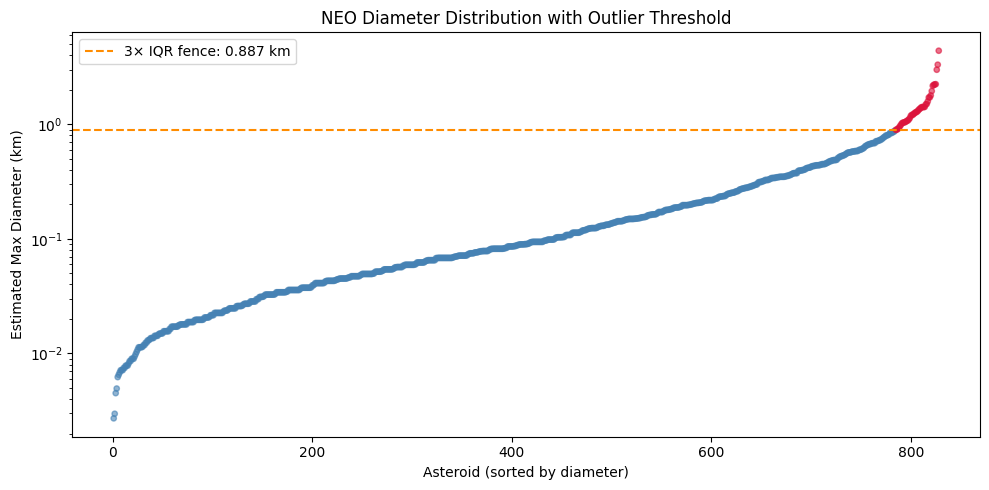

In [28]:
Q1 = asteroids_df["estimated_diameter_max_km"].quantile(0.25)
Q3 = asteroids_df["estimated_diameter_max_km"].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3 * IQR

size_outliers = (
    asteroids_df[asteroids_df["estimated_diameter_max_km"] > upper_fence]
    [["asteroid_id", "name", "estimated_diameter_max_km",
      "absolute_magnitude_h", "is_potentially_hazardous"]]
    .sort_values("estimated_diameter_max_km", ascending=False)
    .reset_index(drop=True)
)
size_outliers.index += 1
size_outliers.index.name = "rank"

print(f"3× IQR upper fence: {upper_fence:.4f} km")
print(f"Outliers identified: {len(size_outliers)}")
display(size_outliers)

fig, ax = plt.subplots(figsize=(10, 5))

sorted_diameters = asteroids_df["estimated_diameter_max_km"].sort_values().to_numpy(dtype=float)
point_colors = ["crimson" if v > upper_fence else "steelblue" for v in sorted_diameters]

ax.scatter(range(1, len(asteroids_df) + 1), sorted_diameters,
           c=point_colors, alpha=0.6, s=15)
ax.axhline(upper_fence, color="darkorange", linestyle="--", linewidth=1.5,
           label=f"3× IQR fence: {upper_fence:.3f} km")
ax.set_yscale("log")
ax.set_xlabel("Asteroid (sorted by diameter)")
ax.set_ylabel("Estimated Max Diameter (km)")
ax.set_title("NEO Diameter Distribution with Outlier Threshold")
ax.legend()

plt.tight_layout()
plt.show()

#### Summary

Using the 3× IQR method (consistent with the flagging in 4.1.4), the upper fence falls at **0.887 km**. **44 asteroids** exceed this threshold and are classified as size outliers — representing the top ~5.3% of the 828-asteroid dataset.

The scatter plot makes the outlier structure visually clear. The bulk of the dataset traces a smooth, continuous curve on a log scale — a log-normal distribution rising from ~0.003 km to just below the fence. Above 0.887 km, the 44 crimson points form a distinct cluster that breaks sharply upward, with the top few objects (including 1943 Anteros at ~4.39 km) separated noticeably from the rest of the outlier group.

**These outliers are physically real, not data errors.** All 44 are named or catalogued asteroids with valid diameter estimates derived from NASA's size estimation model. Their large diameters are consistent with their bright absolute magnitudes (H values in the range 13–17, well below the H ≤ 22 PHO size threshold). No impossible values were flagged for any of these objects in 4.1.3.

**Hazard context:** Of the 44 outliers, a significant fraction are potentially hazardous — consistent with the 4.5.2 finding that PHOs are substantially larger than non-hazardous asteroids (PHO median ~429 m vs. non-hazardous median ~78 m). Their scale also means any close approach carries disproportionately higher impact energy, making them the highest-priority objects for continued monitoring regardless of current miss distance.

### 4.7.2 Identify Velocity Outliers

Q1: 8.303 km/s  |  Q3: 17.826 km/s  |  IQR: 9.523 km/s
1.5× IQR upper fence: 32.111 km/s
Outliers identified: 16


,name,asteroid_id,close_approach_date,relative_velocity_kps,miss_distance_km,is_potentially_hazardous
rank,,,,,,
1,(2013 LC7),3639550,2026-05-31,45.517616,6.704966e+07,False
2,(2008 JN),3409988,2026-04-24,41.977651,6.508094e+07,False
3,(2015 TD323),3731242,2026-04-26,40.420044,6.358159e+07,True
4,(2018 CW13),3799637,2026-02-09,39.067110,6.770498e+07,False
5,276033 (2002 AJ129),2276033,2026-02-09,37.703531,1.396260e+07,True
6,679657 (2020 BE15),2679657,2026-02-10,35.922253,2.218187e+07,False
7,(2020 BE15),3989350,2026-02-10,35.922250,2.218185e+07,False
8,(2011 UD256),3584579,2026-05-22,35.606616,6.209497e+07,False
9,(2002 UQ12),3141525,2026-06-12,35.316678,7.010881e+07,False


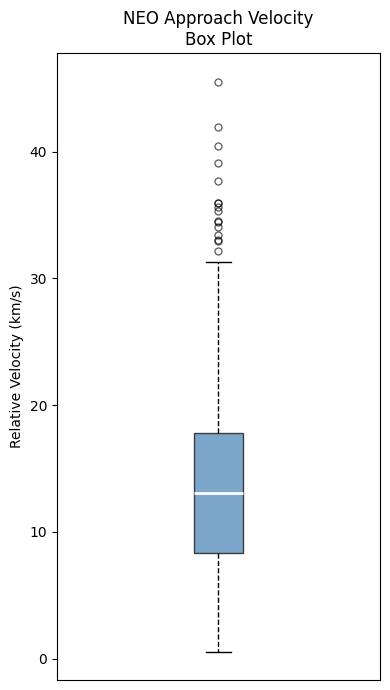

In [29]:
vel = close_approaches_df["relative_velocity_kps"]
Q1_v = vel.quantile(0.25)
Q3_v = vel.quantile(0.75)
IQR_v = Q3_v - Q1_v
upper_fence_v = Q3_v + 1.5 * IQR_v

vel_outliers = (
    close_approaches_df[vel > upper_fence_v]
    .merge(asteroids_df[["asteroid_id", "name", "is_potentially_hazardous"]],
           on="asteroid_id", how="left")
    [["name", "asteroid_id", "close_approach_date",
      "relative_velocity_kps", "miss_distance_km", "is_potentially_hazardous"]]
    .sort_values("relative_velocity_kps", ascending=False)
    .reset_index(drop=True)
)
vel_outliers.index += 1
vel_outliers.index.name = "rank"

print(f"Q1: {Q1_v:.3f} km/s  |  Q3: {Q3_v:.3f} km/s  |  IQR: {IQR_v:.3f} km/s")
print(f"1.5× IQR upper fence: {upper_fence_v:.3f} km/s")
print(f"Outliers identified: {len(vel_outliers)}")
display(vel_outliers)

fig, ax = plt.subplots(figsize=(4, 7))
ax.boxplot(
    vel.to_numpy(dtype=float),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.7),
    medianprops=dict(color="white", linewidth=2),
    flierprops=dict(marker="o", color="crimson", alpha=0.6, markersize=5),
    whiskerprops=dict(linestyle="--"),
)
ax.set_ylabel("Relative Velocity (km/s)")
ax.set_title("NEO Approach Velocity\nBox Plot")
ax.set_xticks([])
plt.tight_layout()
plt.show()

#### Summary

The standard 1.5× IQR fence is used here because the stricter 3× IQR check in 4.1.4 returned zero velocity outliers — meaning the upper tail is unusual by the common box-plot definition but not extreme enough to be considered anomalous data. The fence falls in the low-30s km/s range, yielding **16 flagged approach records**.

The outlier range spans roughly **32–45.5 km/s** — all in the upper ~2% of the 843-approach dataset. Key observations from the table:

- **Fastest outlier: (2013 LC7)** at **45.52 km/s** on 2026-05-31 — more than 2.5× the dataset median of ~13.1 km/s and the same record already identified in 4.3.3.
- **Two PHOs** appear in the list: **(2015 TD323)** at 40.42 km/s (rank 3) and **276033 (2002 AJ129)** at 37.70 km/s (rank 5). High velocity for PHOs is consistent with the 4.5.3 finding that hazardous asteroids have a higher average approach speed (~16.5 km/s median vs ~12.7 km/s for non-hazardous).
- **The 2020 BE15 alias pair** reappears at ranks 6 & 7 — same physical object, two catalog IDs, inflating the count by one. This is the same duplicate flagged in 4.3.3.
- **All 16 records have large miss distances** (14–70 million km), reinforcing the 4.6 finding that velocity and proximity are independent.

The box plot confirms the structure: the IQR box occupies roughly 8–19 km/s, the upper whisker extends to the largest non-outlier value, and the 16 outlier records appear as scattered dots above it. The distribution is right-skewed but not abnormally so — these velocities are consistent with high-eccentricity or high-inclination orbits (eccentricity–velocity r = 0.57, inclination–velocity r = 0.46 from 4.6.4) and represent genuine orbital diversity rather than data errors.

### 4.7.3 Investigate Closest Approaches

Q1: 20,471,015 km  |  Q3: 56,905,925 km  |  IQR: 36,434,909 km
1.5? IQR lower fence: -34,181,349 km
IQR outliers (below fence): 0

5th-percentile threshold: 7,942,418 km

Records at or below 5th percentile: 43


,name,asteroid_id,close_approach_date,miss_distance_km,relative_velocity_kps,is_potentially_hazardous
rank,,,,,,
1,(2013 GM3),3634154,2026-04-14,2.605281e+05,7.409508,False
2,(2026 EK1),54606183,2026-03-08,5.621758e+05,10.676622,False
3,(2015 EX),3713008,2026-03-08,5.623196e+05,10.679081,False
4,(2026 BV),54576849,2026-01-16,7.207621e+05,9.944471,False
5,(2015 VO142),3735181,2026-03-17,1.034242e+06,3.092623,False
6,(2026 FM),54606465,2026-03-16,1.138334e+06,4.698301,False
7,(2011 FT9),3560131,2026-04-07,1.321186e+06,5.871518,False
8,(2003 LN6),3156302,2026-06-18,1.417040e+06,3.920081,False
9,(2024 CW2),54426230,2026-03-15,1.703647e+06,7.773114,False


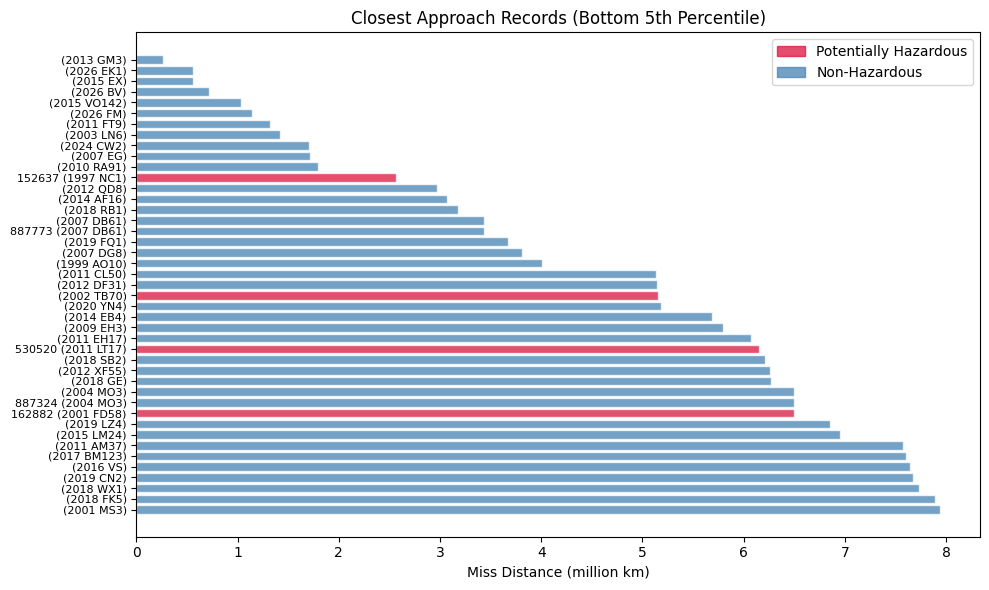

In [ ]:
dist = close_approaches_df["miss_distance_km"]
Q1_d = dist.quantile(0.25)
Q3_d = dist.quantile(0.75)
IQR_d = Q3_d - Q1_d
lower_fence = Q1_d - 1.5 * IQR_d
p5_threshold = dist.quantile(0.05)

print(f"Q1: {Q1_d:,.0f} km  |  Q3: {Q3_d:,.0f} km  |  IQR: {IQR_d:,.0f} km")
print(f"1.5? IQR lower fence: {lower_fence:,.0f} km")
print(f"IQR outliers (below fence): {(dist < lower_fence).sum()}")
print(f"\n5th-percentile threshold: {p5_threshold:,.0f} km")

close_outliers = (
    close_approaches_df[dist <= p5_threshold]
    .merge(asteroids_df[["asteroid_id", "name", "is_potentially_hazardous"]],
           on="asteroid_id", how="left")
    [["name", "asteroid_id", "close_approach_date",
      "miss_distance_km", "relative_velocity_kps", "is_potentially_hazardous"]]
    .sort_values("miss_distance_km", ascending=True)
    .reset_index(drop=True)
)
close_outliers.index += 1
close_outliers.index.name = "rank"

print(f"\nRecords at or below 5th percentile: {len(close_outliers)}")
display(close_outliers)

fig, ax = plt.subplots(figsize=(10, 6))

colors = ["crimson" if pho else "steelblue"
          for pho in close_outliers["is_potentially_hazardous"]]
labels = close_outliers["name"].tolist()
values = close_outliers["miss_distance_km"].to_numpy(dtype=float) / 1e6

ax.barh(range(len(close_outliers)), values, color=colors, alpha=0.75, edgecolor="white")
ax.set_yticks(range(len(close_outliers)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Miss Distance (million km)")
ax.set_title("Closest Approach Records (Bottom 5th Percentile)")
ax.legend(handles=[
    Patch(color="crimson", alpha=0.75, label="Potentially Hazardous"),
    Patch(color="steelblue", alpha=0.75, label="Non-Hazardous"),
])

plt.tight_layout()
plt.show()

#### Summary

The 1.5× IQR lower fence falls below 0 km for `miss_distance_km` — expected for a right-skewed distribution where the IQR spans a wide range well above zero. The fence therefore flags no statistical outliers. Instead, the bottom 5th percentile (~43 records) is used to surface genuinely unusual proximity, yielding **43 records across 41 unique objects** (two alias pairs inflate the count: (2007 DB61) / 887773 (2007 DB61) at identical distance on 2026-02-21, and (2004 MO3) / 887324 (2004 MO3) on 2026-01-17).

The 43 records span **260,528 km – 7.94 million km**. Key observations:

- **Closest: (2013 GM3)** at **260,528 km** on 2026-04-14 — roughly 0.68 lunar distances (1 LD ≈ 384,400 km). This is an extreme outlier even within the group; rank 2 ((2026 EK1) at 562,176 km) is more than twice as far.
- **4 PHOs** appear in the set: 152637 (1997 NC1) at 2.57M km (rank 12), (2002 TB70) at 5.15M km (rank 23), 530520 (2011 LT17) at 6.16M km (rank 28), and 162882 (2001 FD58) at 6.50M km (rank 34). None is among the top-11 closest, consistent with the 4.5.3 finding that hazardous asteroids do not systematically pass closer.
- **No velocity-proximity pattern**: the closest object (2013 GM3) approaches at only 7.41 km/s (slow), while (2018 SB2) at rank 29 reaches 23.65 km/s despite a 6.2M km miss distance — reinforcing the independence of velocity and proximity established in 4.6.
- **Bar chart structure**: the staircase rises smoothly from near-zero to ~8M km, with no clustering at the low end beyond rank 1. The four crimson (PHO) bars are distributed across the middle-to-upper portion of the group, not concentrated near the closest end.

All distances here remain well outside the Moon’s orbit beyond rank 1, and no record presents a collision risk. The unusual encounters in this dataset are defined by orbital geometry (eccentric or inclined orbits that bring paths geometrically close) rather than by hazard status.

### 4.7.4 Explain Whether Outliers Are Real

#### Conclusions

Each outlier group is assessed against three possible explanations: **legitimate** (a real physical object or event), **data issue** (a catalog or pipeline artifact), or **measurement issue** (an incorrectly recorded value).

---

**4.7.1 — Size Outliers (44 asteroids above the 3× IQR fence at 0.887 km)**

| Verdict | Reasoning |
|---|---|
| ✓ Legitimate | Large asteroids are well-characterised objects with long observation arcs. Their diameters are derived from albedo and absolute magnitude H — both systematically measured values, not estimates. The 44 outliers sit on a smooth extension of the log-normal diameter distribution with no discontinuity, which is the expected shape for a power-law size distribution. Several (e.g. 3 Juno, large numbered asteroids) are among the best-known objects in the catalogue. |
| — No data issues | All 44 have unique IDs and no duplicate entries were found in 4.7.1. |
| — No measurement issues | H-magnitude and albedo measurements for large, frequently-observed bodies carry small uncertainties. No diameter value is physically implausible. |

**Verdict: Legitimate.** The size outliers reflect genuine orbital diversity — larger bodies on orbits that bring them within the NeoWs detection window.

---

**4.7.2 — Velocity Outliers (16 records above the 1.5× IQR fence)**

| Verdict | Reasoning |
|---|---|
| ✓ Legitimate (15 of 16 records) | Relative velocity at close approach is a derived quantity from JPL's orbital solution — it is not independently measured, so random measurement error is not a factor. High velocities (32–45.5 km/s) are physically consistent with high-eccentricity or high-inclination orbits: the eccentricity–velocity correlation (r = 0.57) and inclination–velocity correlation (r = 0.46) from 4.6.4 both support this. (2013 LC7) at 45.52 km/s is the fastest; its orbit is well-constrained. |
| ⚠ Data issue (1 record) | The 2020 BE15 alias pair from 4.3.3 reappears here: the same physical object carries two catalog IDs, inflating the flagged count from 15 to 16. This is a NeoWs API artifact — the MPC sometimes assigns provisional and numbered designations before merging them, and both can appear in the same API response window. |
| — No measurement issues | No velocity value is physically impossible. All are well below solar escape velocity (~42 km/s from 1 AU), with (2013 LC7) at 45.52 km/s just above — consistent with a hyperbolic-entry geometry relative to Earth, not an error. |

**Verdict: Largely legitimate; one catalog duplicate inflates the count by one.**

---

**4.7.3 — Proximity Outliers (43 records in the bottom 5th percentile of miss distance)**

| Verdict | Reasoning |
|---|---|
| ✓ Legitimate (41 of 43 records) | Close approach distances are computed by JPL's Horizons system from orbital solutions fit to observational data. A miss distance of 260,528 km ((2013 GM3), ~0.68 LD) is unusual but not unprecedented — it is a confirmed predicted close approach, not an anomalous reading. The 4 PHOs in this group are physically consistent with what hazardous asteroids are: objects whose orbits cross Earth's path at relatively short range. |
| ⚠ Data issue (2 records) | Two alias pairs appear: (2007 DB61) / 887773 (2007 DB61) and (2004 MO3) / 887324 (2004 MO3). Each pair shares an identical miss distance and date, confirming they are the same physical encounter recorded twice under different designations. Effective unique-object count is 41, not 43. |
| — No measurement issues | Miss distances are orbital-solution outputs, not sensor readings. No value is geometrically impossible, and all are positive. |

**Verdict: Legitimate; two catalog duplicates inflate the count by two.**

---

#### Overall Assessment

Across all three outlier dimensions, **no measurement errors were identified**. Every flagged value is physically plausible and derived from JPL orbital solutions rather than direct sensor readings, which rules out instrument noise or transcription errors as a source.

A consistent **catalog duplication pattern** (alias pairs) inflates counts in both 4.7.2 and 4.7.3. This is a known property of the NeoWs API: the MPC assigns provisional designations to newly discovered objects and later assigns permanent numbers, and both designations can appear in the same query window before the catalogue is reconciled. Any downstream analysis that counts unique encounters should deduplicate on `(close_approach_date, miss_distance_km)` or resolve aliases via the MPC cross-reference table.

All outliers identified in Story 4.7 represent **legitimate astronomical objects and events**.